Importing Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


Load the processed data

In [27]:
df = pd.read_csv('../data/processed/Telco-Customer-Churn-processed.csv')
df.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [28]:
df.shape
df.isnull().sum().sum()


np.int64(0)

Separate target and features

In [29]:
target = 'Churn'
features = df.drop(columns=[target])


Churn vs Tenure

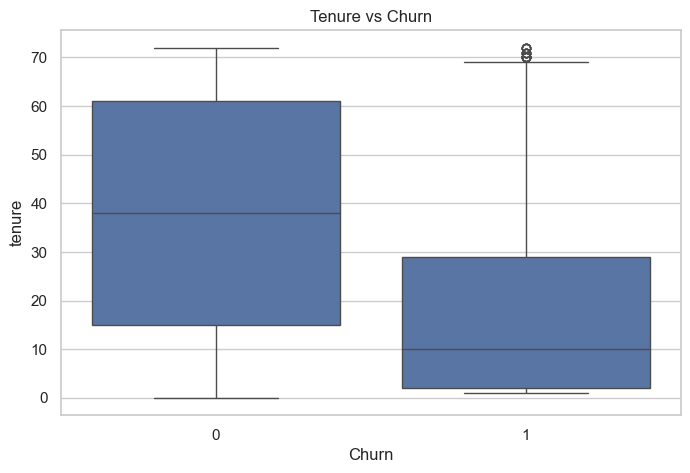

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()


Observation: Tenure vs Churn
- Customers who churn tend to have significantly lower tenure
- Long-term customers are more likely to stay
- Tenure appears to be a strong predictive feature


Monthly Charges vs Churn

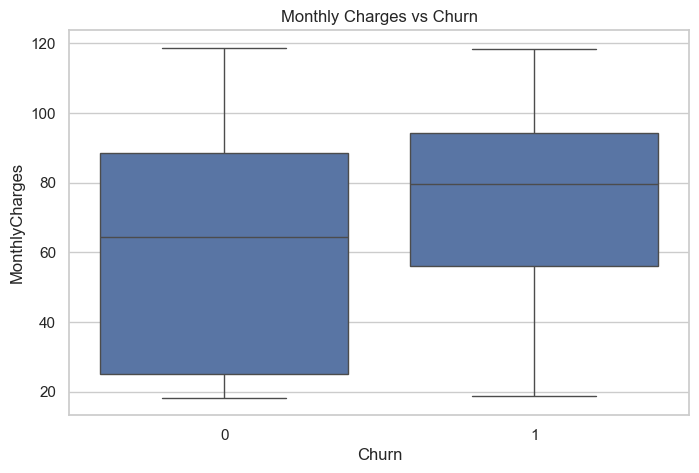

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()


 Observation: Monthly Charges vs Churn
- Churned customers tend to have higher monthly charges
- Indicates potential price sensitivity


Contract Type

In [32]:
contract_cols = [col for col in df.columns if 'Contract_' in col]

df.groupby('Churn')[contract_cols].mean()


,Contract_One year,Contract_Two year
Churn,,
0,0.252609,0.318322
1,0.088818,0.025682


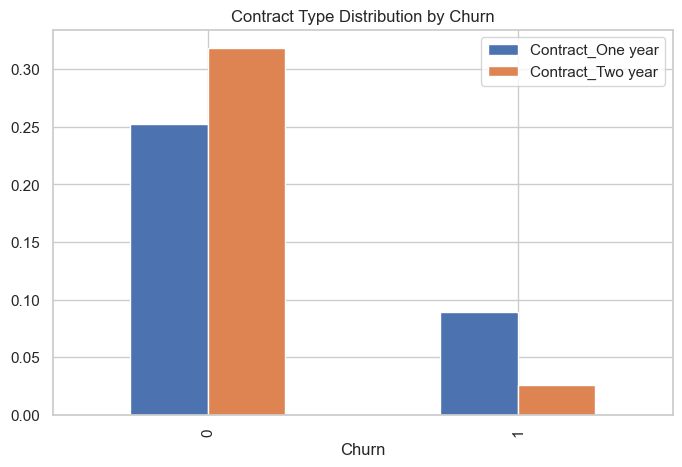

In [33]:
df.groupby('Churn')[contract_cols].mean().plot(kind='bar', figsize=(8,5))
plt.title('Contract Type Distribution by Churn')
plt.show()


 Observation: Contract Type
- Month-to-month contracts strongly associated with churn
- Long-term contracts reduce churn significantly
- Contract type is a high-value feature


Correlation with target

In [34]:
corr = df.corr()['Churn'].sort_values(ascending=False)
corr


Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


Correlation Analysis Insights

- Tenure shows the strongest negative correlation with churn, indicating that customer churn is most likely early in the customer lifecycle
- Month-to-month style behaviors such as electronic check payments and paperless billing are positively correlated with churn
- Fiber optic customers exhibit higher churn, likely due to higher pricing and service expectations
- Long-term contracts (one year and two year) significantly reduce churn risk
- Demographic features such as gender show negligible correlation with churn
